# 4DVarNet — Field Reconstruction with UNet Gradient Model (SPDE Diffusion Dataset)

Adaptation of the SSH 4DVarNet-UNet notebook to the **SPDE diffusion GP dataset**.

Dataset: `SPDE_diffusion_dataset.nc`
- **`x`** `(time, lat, lon)` — ground truth field
- **`y`** `(time, lat, lon)` — sparse observations (NaN where unobserved)
- **`OI`** `(time, lat, lon)` — Optimal Interpolation baseline (benchmarking only)

The architecture and solver are identical to the SSH notebook.  
Only the **DataModule** and **evaluation section** differ (OI benchmark added).

| UNet input | Shape | Description |
|-----------|-------|-------------|
| $x_k$ | `(B, C, H, W)` | Current state |
| $\nabla_x J(x_k)$ | `(B, C, H, W)` | Variational cost gradient |
| $t_k$ | scalar | Normalised solver step → sinusoidal embedding |

Cost: $J(x) = \|m \odot (x - y)\|^2 + \alpha \|x - \text{AE}(x)\|^2$


## 🛠️ Setup & Imports

In [26]:
!nvidia-smi


Thu Apr 16 21:23:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:4A:00.0 Off |                    0 |
|  0%   35C    P0             75W /  300W |   27623MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [27]:
%env CUDA_VISIBLE_DEVICES=2


env: CUDA_VISIBLE_DEVICES=2


In [28]:
import json
import math
import os
import zipfile
import glob
from dataclasses import asdict, dataclass
from typing import List, Optional, Tuple, Union

import numpy as np
import xarray as xr
import pandas as pd
import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torchinfo import summary

import sys
sys.path.append('../../..')


## ⚙️ Solver Choice

Set `SOLVER_TYPE` to `"unet"` or `"lstm"` to switch between the two gradient models.

| `SOLVER_TYPE` | Gradient model | Notes |
|---|---|---|
| `"unet"` | `GradSolverUNet` (U-Net + sinusoidal time embedding) | Richer capacity, slower per step |
| `"lstm"` | `ConvLstmGradModel` (ConvLSTM) | Lighter, stateful across solver steps |


In [29]:
# ── Choose your gradient model ────────────────────────────────────────────────
SOLVER_TYPE = "lstm"   # "unet"  |  "lstm"
# ──────────────────────────────────────────────────────────────────────────────
assert SOLVER_TYPE in ("unet", "lstm"), f"Unknown SOLVER_TYPE: {SOLVER_TYPE!r}"
print(f"Solver type selected: {SOLVER_TYPE.upper()}")


Solver type selected: LSTM


## 🧠 Implementation

### DataModule — SPDE Diffusion Dataset

Load the NetCDF and inspect variables, then instantiate the `SPDEDataModule` from `src/data_notebook_spde.py`.


In [30]:
from src.data_notebook_spde import SPDEDataModule

SPDE_PATH = "/data/users/maxb/4dvarnet-starter-devs/SPDE/SPDE_diffusion_dataset_2.nc"

# ---- Quick dataset inspection ----
ds_inspect = xr.open_dataset(SPDE_PATH)
print(ds_inspect)
print("\nVariables:")
for v in ds_inspect.data_vars:
    print(f"  {v}: {ds_inspect[v].dims}  shape={ds_inspect[v].shape}  dtype={ds_inspect[v].dtype}")
ds_inspect.close()


<xarray.Dataset> Size: 79MB
Dimensions:    (time: 300, lat: 128, lon: 128)
Coordinates:
  * lon        (lon) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * lat        (lat) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * time       (time) int64 2kB 0 1 2 3 4 5 6 7 ... 293 294 295 296 297 298 299
Data variables:
    x          (time, lat, lon) float32 20MB ...
    y          (time, lat, lon) float32 20MB ...
    OI         (time, lat, lon) float64 39MB ...
    H11        (lat, lon) float32 66kB ...
    H22        (lat, lon) float32 66kB ...
    H12        (lat, lon) float32 66kB ...
    Time       (time) int64 2kB ...
    longitude  (lon) int64 1kB ...
    latitude   (lat) int64 1kB ...
Attributes:
    description:  SPDE-based diffusion GP

Variables:
  x: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  y: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  OI: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float64
  H11: ('la

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45
[SPDEDataModule] Norm stats (mean, std): (0.004648688714951277, 0.3709214925765991)
TrainingItem shapes — input (y): (5, 128, 128), tgt (x): (5, 128, 128)
[SPDEDataModule] Norm stats (mean, std): (0.004648688714951277, 0.3709214925765991)
TrainingItem shapes — input (y): (5, 128, 128), tgt (x): (5, 128, 128)


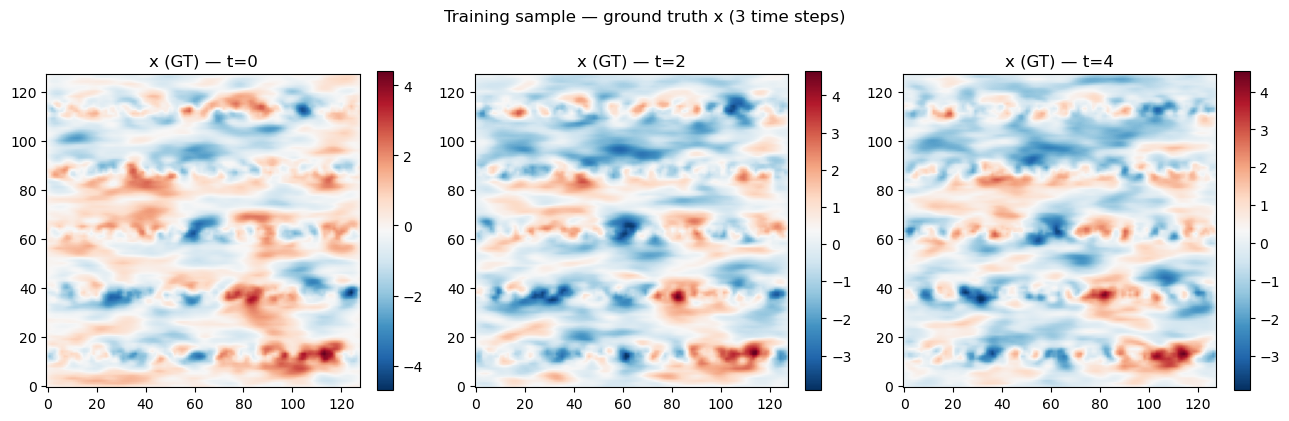

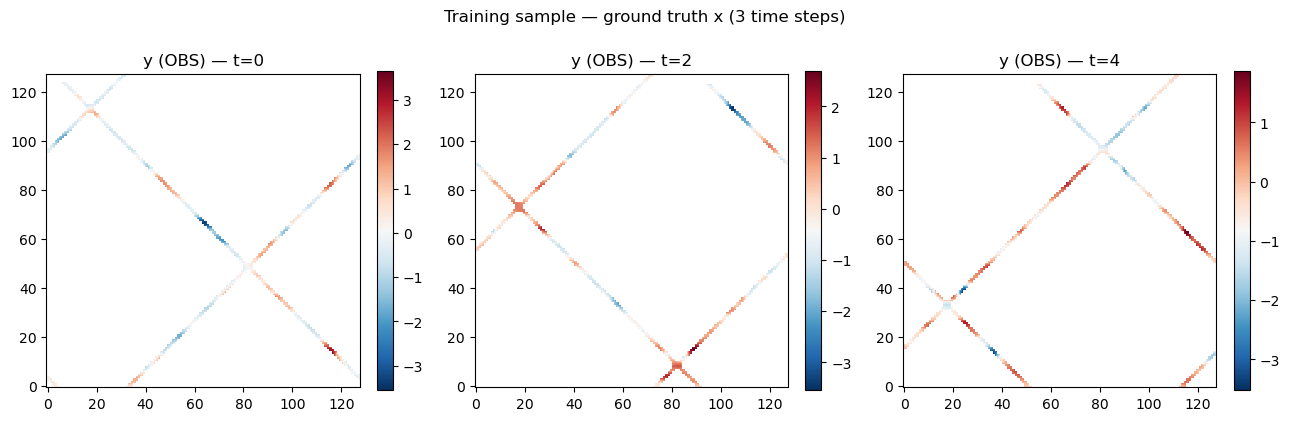

In [31]:
# ---- DataModule ----
# The full dataset is T=15, H=100, W=100.
# window_size=15 → each sample is the full temporal extent.
# stride=1 → only one window (size 1 dataset); use smaller window_size
# to create more samples if needed (e.g. window_size=5, stride=1 → 11 windows).

datamodule = SPDEDataModule(
    path=SPDE_PATH,
    window_size=5,          # full temporal extent per sample
    stride=1,
    train_ratio=0.7,
    val_ratio=0.15,
    dl_kw={"batch_size": 1, "num_workers": 1},
)
datamodule.setup()

# ---- Sanity plot — first training sample (ground truth x) ----
sample = datamodule.train_ds[0]
print(f"TrainingItem shapes — input (y): {sample.input.shape}, tgt (x): {sample.tgt.shape}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for t_idx, ax in zip([0, 2, 4], axes):
    im = ax.imshow(sample.tgt[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"x (GT) — t={t_idx}")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Training sample — ground truth x (3 time steps)", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for t_idx, ax in zip([0, 2, 4], axes):
    im = ax.imshow(sample.input[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"y (OBS) — t={t_idx}")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Training sample — ground truth x (3 time steps)", y=1.02)
plt.tight_layout()
plt.show()



### UNet Modules (dataset-agnostic — copied from reference notebook)

In [32]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.dropout = dropout
        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)
        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])
        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 noise_level_channels: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            GroupNorm(in_channels), nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.noise_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(noise_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, cond: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.noise_level_projection(cond)
        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 noise_level_channels: int, n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.unet_block = UNetBlock(in_channels, out_channels, noise_level_channels, dropout)
        self.self_attention = SelfAttention(out_channels, out_channels, n_heads, dropout)

    def forward(self, x: Tensor, cond: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, cond))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )
    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )
    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


### Sinusoidal Time Embedding

Solver step $t_k = k/(N-1) \in [0,1]$ → conditioning vector `(B, D, 1, 1)` injected into each UNetBlock.


In [33]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int = 128, out_dim: Optional[int] = None) -> None:
        super().__init__()
        out_dim = out_dim or dim
        half = dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, dtype=torch.float32) / (half - 1)
        )
        self.register_buffer("freqs", freqs)
        self.mlp = nn.Sequential(
            nn.Linear(dim, 4 * dim),
            nn.SiLU(),
            nn.Linear(4 * dim, out_dim),
        )

    def forward(self, t: Tensor) -> Tensor:
        if t.dim() == 0:
            t = t.unsqueeze(0)
        t = t.float()
        angles = t[:, None] * self.freqs[None, :]
        emb = torch.cat([angles.sin(), angles.cos()], dim=-1)
        emb = emb.to(dtype=next(self.mlp.parameters()).dtype)
        emb = self.mlp(emb)
        return emb[:, :, None, None]


### UNet Gradient Model

`GradSolverUNetConfig.channels` is set to the **number of time steps per patch** (= `window_size` = 15).


In [34]:
@dataclass
class GradSolverUNetConfig:
    channels: int = 5                                     # C = window_size (time steps per patch)
    time_emb_dim: int = 128
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (56, 56)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (128, 256)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)


def _pad_to_multiple(x: Tensor, multiple: int = 8) -> Tuple[Tensor, Tuple[int, int, int, int]]:
    """Pad H and W to the nearest multiple of `multiple` using reflection padding."""
    _, _, H, W = x.shape
    pad_h = (multiple - H % multiple) % multiple
    pad_w = (multiple - W % multiple) % multiple
    # F.pad: (left, right, top, bottom)
    padding = (0, pad_w, 0, pad_h)
    return F.pad(x, padding, mode="reflect"), padding


def _unpad(x: Tensor, padding: Tuple[int, int, int, int]) -> Tensor:
    """Remove the padding added by _pad_to_multiple."""
    _, pad_w, _, pad_h = padding
    H, W = x.shape[-2], x.shape[-1]
    return x[..., :H - pad_h if pad_h else H, :W - pad_w if pad_w else W]


class GradSolverUNet(nn.Module):
    def __init__(self, config: GradSolverUNetConfig) -> None:
        super().__init__()
        self.config = config
        C   = config.channels
        D   = config.top_blocks_channels[0]
        EMB = config.time_emb_dim

        self.time_embedding    = SinusoidalTimeEmbedding(dim=EMB, out_dim=EMB)
        self.input_projection  = nn.Conv2d(2 * C, D, kernel_size=3, padding="same")

        self.top_encoder_blocks = self._make_encoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block)
        self.mid_encoder_blocks = self._make_encoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block)
        self.mid_decoder_blocks = self._make_decoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block)
        self.top_decoder_blocks = self._make_decoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block)

        self.output_projection = nn.Conv2d(D, C, kernel_size=3, padding="same")

    def forward(self, x: Tensor, grad_j: Tensor, t: Tensor) -> Tensor:
        grad_norm = (grad_j ** 2).mean().sqrt().clamp(min=1e-8)
        grad_j_n  = grad_j / grad_norm

        # Pad both inputs to a multiple of 8 so Downsample never gets odd dims
        inp = torch.cat([x, grad_j_n], dim=1)
        inp, padding = _pad_to_multiple(inp, multiple=8)

        h    = self.input_projection(inp)
        cond = self.time_embedding(t)

        top_skips = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, cond); top_skips.append(h)
            else:
                h = block(h)

        mid_skips = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, cond); mid_skips.append(h)
            else:
                h = block(h)

        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_skips.pop()), dim=1); h = block(h, cond)
            else:
                h = block(h)

        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_skips.pop()), dim=1); h = block(h, cond)
            else:
                h = block(h)

        out = self.output_projection(h)
        return _unpad(out, padding)   # restore original H×W

    def _make_encoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (ic, oc) in enumerate(zip(channels[:-1], channels[1:])):
            for _ in range(n_blocks[idx]):
                blocks.append(block_fn(ic, oc, dropout[idx])); ic = oc
            if has_resampling[idx]:
                blocks.append(Downsample(oc))
        return blocks

    def _make_decoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (oc, ic) in enumerate(list(zip(channels[:-1], channels[1:]))[::-1]):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(ic))
            inner = []
            for _ in range(n_blocks[::-1][idx]):
                inner.append(block_fn(ic * 2, oc, dropout[::-1][idx])); oc = ic
            blocks.extend(inner[::-1])
        return blocks

    def _make_top_block(self, ic, oc, dropout):
        return UNetBlock(ic, oc, self.config.time_emb_dim, dropout)

    def _make_mid_block(self, ic, oc, dropout):
        return UNetBlockWithSelfAttention(ic, oc, self.config.time_emb_dim, self.config.n_heads, dropout)

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config_4dvarnet_unet.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model_4dvarnet_unet.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "GradSolverUNet":
        with open(os.path.join(pretrained_path, "config_4dvarnet_unet.json"), mode="r") as f:
            config_dict = json.load(f)
        model = cls(GradSolverUNetConfig(**config_dict))
        model.load_state_dict(torch.load(
            os.path.join(pretrained_path, "model_4dvarnet_unet.pt"), map_location="cpu"))
        return model


# Sanity check — 100×100 will be padded to 104×104 internally
C = datamodule.window_size
summary(
    GradSolverUNet(GradSolverUNetConfig(channels=C)),
    input_data=[
        torch.zeros(1, C, 100, 100),
        torch.zeros(1, C, 100, 100),
        torch.tensor([0.5]),
    ],
)


Layer (type:depth-idx)                        Output Shape              Param #
GradSolverUNet                                [1, 5, 100, 100]          --
├─Conv2d: 1-1                                 [1, 56, 104, 104]         5,096
├─SinusoidalTimeEmbedding: 1-2                [1, 128, 1, 1]            --
│    └─Sequential: 2-1                        [1, 128]                  --
│    │    └─Linear: 3-1                       [1, 512]                  66,048
│    │    └─SiLU: 3-2                         [1, 512]                  --
│    │    └─Linear: 3-3                       [1, 128]                  65,664
├─ModuleList: 1-3                             --                        --
│    └─UNetBlock: 2-2                         [1, 56, 104, 104]         --
│    │    └─Sequential: 3-4                   [1, 56, 104, 104]         28,392
│    │    └─Sequential: 3-5                   [1, 56, 1, 1]             7,224
│    │    └─Sequential: 3-6                   [1, 56, 104, 104]         28,39

### Observation Operator & Variational Cost

$J(x) = \|m \odot (x - y)\|^2 + \alpha\,\|x - \text{AE}(x)\|^2$

Mask derived from finite values: `mask = y.isfinite()`, `y_filled = y.nan_to_num(0.0)`.


In [35]:
class ObsCost(nn.Module):
    def __init__(self, w: float = 1.0) -> None:
        super().__init__()
        self.w = w

    def forward(self, state: Tensor, y_filled: Tensor, mask: Tensor) -> Tensor:
        return self.w * F.mse_loss(state * mask, y_filled * mask)


class BilinAEPriorCost(nn.Module):
    def __init__(self, dim_in: int, dim_hidden: int,
                 kernel_size: int = 3, downsamp: Optional[int] = None,
                 bilin_quad: bool = True) -> None:
        super().__init__()
        self.bilin_quad = bilin_quad
        self.conv_in     = nn.Conv2d(dim_in, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.conv_hidden = nn.Conv2d(dim_hidden, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.bilin_1     = nn.Conv2d(dim_hidden, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.bilin_21    = nn.Conv2d(dim_hidden, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.bilin_22    = nn.Conv2d(dim_hidden, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.conv_out    = nn.Conv2d(2 * dim_hidden, dim_in, kernel_size, padding=kernel_size // 2)
        self.down = nn.AvgPool2d(downsamp) if downsamp else nn.Identity()
        self.up   = nn.UpsamplingBilinear2d(scale_factor=downsamp) if downsamp else nn.Identity()

    def forward_ae(self, x: Tensor) -> Tensor:
        x = self.down(x)
        x = self.conv_hidden(F.relu(self.conv_in(x)))
        nonlin = self.bilin_21(x) ** 2 if self.bilin_quad else self.bilin_21(x) * self.bilin_22(x)
        x = self.conv_out(torch.cat([self.bilin_1(x), nonlin], dim=1))
        return self.up(x)

    def forward(self, state: Tensor) -> Tensor:
        return F.mse_loss(state, self.forward_ae(state))


def compute_grad_j(state, y_filled, mask, obs_cost, prior_cost, alpha=1.0):
    x = state.requires_grad_(True)
    J = obs_cost(x, y_filled, mask) + alpha * prior_cost(x)
    return torch.autograd.grad(J, x, create_graph=True)[0]


### 4DVarNet Solver

$x_{k+1} = x_k - \text{UNet}(x_k,\; \nabla_x J(x_k),\; t_k)$,  with $x_0 = y_\text{filled}$


In [36]:
class Solver4DVarUNet(nn.Module):
    def __init__(self, grad_model, obs_cost, prior_cost,
                 n_solver: int = 15, alpha_prior: float = 0.2) -> None:
        super().__init__()
        self.grad_model  = grad_model
        self.obs_cost    = obs_cost
        self.prior_cost  = prior_cost
        self.n_solver    = n_solver
        self.alpha_prior = alpha_prior

    def forward(self, y_filled: Tensor, mask: Tensor,
                return_all_iterates: bool = False) -> Union[Tensor, List[Tensor]]:
        B, C, H, W = y_filled.shape
        device, dtype = y_filled.device, y_filled.dtype
        x = y_filled.clone()
        iterates = [x] if return_all_iterates else None

        with torch.set_grad_enabled(True):
            for k in range(self.n_solver):
                t_k = torch.full((B,), k / max(self.n_solver - 1, 1), device=device, dtype=dtype)
                grad_j = compute_grad_j(x, y_filled, mask, self.obs_cost, self.prior_cost, self.alpha_prior)
                dx = self.grad_model(x, grad_j, t_k)
                x  = x - dx
                if not self.training:
                    x = x.detach().requires_grad_(True)
                if return_all_iterates:
                    iterates.append(x)

        return iterates if return_all_iterates else x


### ConvLSTM Gradient Model & Solver (alternative to UNet)

`ConvLstmGradModel` maintains a hidden/cell state across solver iterations — it takes only $\nabla_x J$ as input (no $x$ or $t_k$).

The update rule follows the original 4DVarNet formulation:

$$x_{k+1} = x_k - \left[\frac{1}{k+1}\,\text{LSTM}(\nabla_x J_k) + \eta\,\frac{k+1}{N}\,\nabla_x J_k\right]$$

where $\eta$ is `lr_grad`.


In [37]:
@dataclass
class Lit4DVarUNetConfig:
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)
    lr_scheduler_start_factor: float = 1e-5
    lr_scheduler_iters: int = 10_000
    intermediate_supervision: bool = False


class Lit4DVarUNet(pl.LightningModule):
    def __init__(self, solver,
                 config: Lit4DVarUNetConfig = Lit4DVarUNetConfig()) -> None:
        super().__init__()
        self.solver = solver
        self.config = config

    @staticmethod
    def _prepare_inputs(y: Tensor) -> Tuple[Tensor, Tensor]:
        mask     = y.isfinite().to(y.dtype)
        y_filled = y.nan_to_num(0.0)
        return y_filled, mask

    def training_step(self, batch, batch_idx):
        if isinstance(batch, list):
            batch = batch[0]
        y_filled, mask = self._prepare_inputs(batch.input)
        tgt = batch.tgt

        if self.config.intermediate_supervision:
            iterates = self.solver(y_filled, mask, return_all_iterates=True)
            N = len(iterates) - 1
            weights = torch.arange(1, N + 2, dtype=tgt.dtype, device=tgt.device)
            weights = weights / weights.sum()
            loss = sum(w * F.mse_loss(xk, tgt) for xk, w in zip(iterates, weights))
        else:
            loss = F.mse_loss(self.solver(y_filled, mask), tgt)

        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        if isinstance(batch, list):
            batch = batch[0]
        y_filled, mask = self._prepare_inputs(batch.input)
        x_final = self.solver(y_filled, mask)
        loss = F.mse_loss(x_final, batch.tgt)
        self.log_dict({"val_loss": loss, "val_rmse": loss.sqrt()}, prog_bar=True)
        return loss

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.config.lr, betas=self.config.betas)
        sched = torch.optim.lr_scheduler.LinearLR(
            opt, start_factor=self.config.lr_scheduler_start_factor,
            end_factor=1.0, total_iters=self.config.lr_scheduler_iters)
        return [opt], [{"scheduler": sched, "interval": "step"}]


In [38]:
@dataclass
class ConvLstmGradModelConfig:
    channels: int = 5          # C = window_size
    dim_hidden: int = 96
    kernel_size: int = 3
    dropout: float = 0.1
    downsamp: Optional[int] = None


class ConvLstmGradModel(nn.Module):
    """Stateful ConvLSTM gradient model — hidden/cell state persists across solver steps."""

    def __init__(self, config: ConvLstmGradModelConfig) -> None:
        super().__init__()
        self.config = config
        C   = config.channels
        H   = config.dim_hidden
        K   = config.kernel_size
        pad = K // 2

        # Project input grad → hidden space
        self.input_proj = nn.Conv2d(C, H, K, padding=pad)

        # LSTM gates (input + hidden → 4*H)
        self.lstm_gates = nn.Conv2d(2 * H, 4 * H, K, padding=pad)

        self.dropout = nn.Dropout2d(config.dropout)
        self.output_proj = nn.Conv2d(H, C, K, padding=pad)

        # Will hold (h, c) between solver iterations
        self._h: Optional[Tensor] = None
        self._c: Optional[Tensor] = None

        if config.downsamp:
            self.down = nn.AvgPool2d(config.downsamp)
            self.up   = nn.UpsamplingBilinear2d(scale_factor=config.downsamp)
        else:
            self.down = nn.Identity()
            self.up   = nn.Identity()

    def reset_state(self) -> None:
        self._h = None
        self._c = None

    def forward(self, grad_j: Tensor) -> Tensor:
        x = self.down(grad_j)
        B, C, H, W = x.shape
        device, dtype = x.device, x.dtype

        h = self._h if self._h is not None else torch.zeros(B, self.config.dim_hidden, H, W, device=device, dtype=dtype)
        c = self._c if self._c is not None else torch.zeros_like(h)

        inp = self.dropout(F.silu(self.input_proj(x)))
        gates = self.lstm_gates(torch.cat([inp, h], dim=1))
        i_g, f_g, g_g, o_g = gates.chunk(4, dim=1)
        c = torch.sigmoid(f_g) * c + torch.sigmoid(i_g) * torch.tanh(g_g)
        h = torch.sigmoid(o_g) * torch.tanh(c)

        self._h = h
        self._c = c

        out = self.output_proj(h)
        return self.up(out)

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config_lstm.json"), "w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model_lstm.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "ConvLstmGradModel":
        with open(os.path.join(pretrained_path, "config_lstm.json"), "r") as f:
            cfg = json.load(f)
        model = cls(ConvLstmGradModelConfig(**cfg))
        model.load_state_dict(torch.load(
            os.path.join(pretrained_path, "model_lstm.pt"), map_location="cpu"))
        return model


class Solver4DVarLSTM(nn.Module):
    """4DVarNet solver using a stateful ConvLSTM gradient model."""

    def __init__(self, grad_model: ConvLstmGradModel, obs_cost, prior_cost,
                 n_solver: int = 15, lr_grad: float = 1e-3, alpha_prior: float = 0.2) -> None:
        super().__init__()
        self.grad_model  = grad_model
        self.obs_cost    = obs_cost
        self.prior_cost  = prior_cost
        self.n_solver    = n_solver
        self.lr_grad     = lr_grad
        self.alpha_prior = alpha_prior

    def forward(self, y_filled: Tensor, mask: Tensor,
                return_all_iterates: bool = False) -> Union[Tensor, List[Tensor]]:
        x = y_filled.clone()
        self.grad_model.reset_state()
        iterates = [x] if return_all_iterates else None

        with torch.set_grad_enabled(True):
            for k in range(self.n_solver):
                grad_j = compute_grad_j(x, y_filled, mask, self.obs_cost, self.prior_cost, self.alpha_prior)
                lstm_out = self.grad_model(grad_j)
                # Update rule: x_{k+1} = x_k - [1/(k+1) * LSTM(∇J) + η*(k+1)/N * ∇J]
                x = x - (lstm_out / (k + 1) + self.lr_grad * (k + 1) / self.n_solver * grad_j)
                if not self.training:
                    x = x.detach().requires_grad_(True)
                if return_all_iterates:
                    iterates.append(x)

        return iterates if return_all_iterates else x


In [39]:
def is_valid_checkpoint(path: str) -> bool:
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False


def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last_ckpt = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last_ckpt) and is_valid_checkpoint(last_ckpt):
        print(f"✅ Valid checkpoint: {last_ckpt}")
        return last_ckpt
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt"))
         if "last" not in os.path.basename(p)],
        key=lambda p: float(p.split("val_loss=")[-1].replace(".ckpt", ""))
        if "val_loss=" in p else float("inf"),
    )
    for ckpt_path in all_ckpts:
        if is_valid_checkpoint(ckpt_path):
            print(f"✅ Valid checkpoint: {ckpt_path}")
            return ckpt_path
    print("❌ No valid checkpoint found. Starting from scratch.")
    return None


C = datamodule.window_size   # time steps per patch

LOG_DIR     = f"logs_4dvarnet_{SOLVER_TYPE}_spde"
LOG_VERSION = "v1"
CKPT_DIR    = os.path.join(LOG_DIR, LOG_VERSION, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, LOG_VERSION, "best_model")
resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

obs_cost   = ObsCost(w=1.0)
prior_cost = BilinAEPriorCost(dim_in=C, dim_hidden=64, bilin_quad=False, downsamp=2)

if SOLVER_TYPE == "unet":
    grad_model = GradSolverUNet(GradSolverUNetConfig(channels=C))
    solver = Solver4DVarUNet(grad_model, obs_cost, prior_cost, n_solver=15, alpha_prior=0.2)
    print("▶ Using UNet gradient model")
else:  # "lstm"
    grad_model = ConvLstmGradModel(ConvLstmGradModelConfig(channels=C, dim_hidden=96))
    solver = Solver4DVarLSTM(grad_model, obs_cost, prior_cost,
                              n_solver=15, lr_grad=1e-3, alpha_prior=0.2)
    print("▶ Using ConvLSTM gradient model")

lit = Lit4DVarUNet(solver, Lit4DVarUNetConfig(lr_scheduler_iters=500, intermediate_supervision=True))

trainer = Trainer(
    accelerator="gpu",
    max_epochs=502,
    accumulate_grad_batches=4,
    precision="16-mixed",
    log_every_n_steps=1,
    logger=TensorBoardLogger(".", name=LOG_DIR, version=LOG_VERSION),
    callbacks=[
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath=CKPT_DIR,
            monitor="val_loss",
            save_top_k=3,
            save_last=True,
            filename="{epoch:03d}-{step}-{val_loss:.4f}",
        ),
    ],
)

seed_everything(42)
trainer.fit(lit, datamodule, ckpt_path=resume_ckpt)

# Save grad_model + prior_cost (both have learned weights)
grad_model.save_pretrained(MODEL_PATH)
os.makedirs(MODEL_PATH, exist_ok=True)
torch.save(prior_cost.state_dict(), os.path.join(MODEL_PATH, "prior_cost.pt"))
print(f"✅ Model saved to: {MODEL_PATH}")


Using 16bit Automatic Mixed Precision (AMP)


▶ Using ConvLSTM gradient model


/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
You are using a CUDA device ('NVIDIA A40') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
You are usi

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45


Sanity Checking: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=502` reached.


✅ Model saved to: logs_4dvarnet_lstm_spde/v1/best_model


## 🚀 Training

In [40]:
def is_valid_checkpoint(path: str) -> bool:
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False


def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last_ckpt = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last_ckpt) and is_valid_checkpoint(last_ckpt):
        print(f"✅ Valid checkpoint: {last_ckpt}")
        return last_ckpt
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt"))
         if "last" not in os.path.basename(p)],
        key=lambda p: float(p.split("val_loss=")[-1].replace(".ckpt", ""))
        if "val_loss=" in p else float("inf"),
    )
    for ckpt_path in all_ckpts:
        if is_valid_checkpoint(ckpt_path):
            print(f"✅ Valid checkpoint: {ckpt_path}")
            return ckpt_path
    print("❌ No valid checkpoint found. Starting from scratch.")
    return None


C = datamodule.window_size   # time steps per patch

LOG_DIR     = f"logs_4dvarnet_{SOLVER_TYPE}_spde"
LOG_VERSION = "v1"
CKPT_DIR    = os.path.join(LOG_DIR, LOG_VERSION, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, LOG_VERSION, "best_model")
resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

obs_cost   = ObsCost(w=1.0)
prior_cost = BilinAEPriorCost(dim_in=C, dim_hidden=64, bilin_quad=False, downsamp=2)

if SOLVER_TYPE == "unet":
    grad_model = GradSolverUNet(GradSolverUNetConfig(channels=C))
    solver = Solver4DVarUNet(grad_model, obs_cost, prior_cost, n_solver=15, alpha_prior=0.2)
    print("▶ Using UNet gradient model")
else:  # "lstm"
    grad_model = ConvLstmGradModel(ConvLstmGradModelConfig(channels=C, dim_hidden=96))
    solver = Solver4DVarLSTM(grad_model, obs_cost, prior_cost,
                              n_solver=15, lr_grad=1e-3, alpha_prior=0.2)
    print("▶ Using ConvLSTM gradient model")

lit = Lit4DVarUNet(solver, Lit4DVarUNetConfig(lr_scheduler_iters=500, intermediate_supervision=True))

trainer = Trainer(
    accelerator="gpu",
    max_epochs=502,
    accumulate_grad_batches=4,
    precision="16-mixed",
    log_every_n_steps=1,
    logger=TensorBoardLogger(".", name=LOG_DIR, version=LOG_VERSION),
    callbacks=[
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath=CKPT_DIR,
            monitor="val_loss",
            save_top_k=3,
            save_last=True,
            filename="{epoch:03d}-{step}-{val_loss:.4f}",
        ),
    ],
)

seed_everything(42)
trainer.fit(lit, datamodule, ckpt_path=resume_ckpt)

grad_model.save_pretrained(MODEL_PATH)
print(f"✅ Model saved to: {MODEL_PATH}")


Using 16bit Automatic Mixed Precision (AMP)


✅ Valid checkpoint: logs_4dvarnet_lstm_spde/v1/checkpoints/last.ckpt
▶ Using ConvLSTM gradient model


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:617: UserWarning: Checkpoint directory logs_4dvarnet_lstm_spde/v1/checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
Restoring states from the checkpoint path at logs_4dvarnet_lstm_spde/v1/checkpoints/last.ckpt
/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:617: UserWarning: Checkpoint directory logs_4dvarnet_lstm_spde/v1/checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is 

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45


Sanity Checking: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=502` reached.


✅ Model saved to: logs_4dvarnet_lstm_spde/v1/best_model


## 🔍 Evaluation & Visualisation

### Load checkpoint


In [41]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype  = torch.bfloat16 if torch.cuda.is_available() else torch.float32

C = datamodule.window_size

obs_cost = ObsCost(w=1.0).to(device=device, dtype=dtype)

# Reload prior_cost with its *trained* weights (learned jointly with grad_model)
prior_cost = BilinAEPriorCost(dim_in=C, dim_hidden=64, bilin_quad=False, downsamp=2)
prior_cost.load_state_dict(torch.load(os.path.join(MODEL_PATH, "prior_cost.pt"), map_location="cpu"))
prior_cost = prior_cost.eval().to(device=device, dtype=dtype)
print("▶ Loaded prior_cost weights from:", MODEL_PATH)

if SOLVER_TYPE == "unet":
    grad_model = GradSolverUNet.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
    solver = Solver4DVarUNet(
        grad_model=grad_model, obs_cost=obs_cost, prior_cost=prior_cost,
        n_solver=15, alpha_prior=0.2,
    ).eval().to(device=device, dtype=dtype)
    print("▶ Loaded UNet gradient model from:", MODEL_PATH)
else:  # "lstm"
    grad_model = ConvLstmGradModel.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
    solver = Solver4DVarLSTM(
        grad_model=grad_model, obs_cost=obs_cost, prior_cost=prior_cost,
        n_solver=15, lr_grad=1e-3, alpha_prior=0.2,
    ).eval().to(device=device, dtype=dtype)
    print("▶ Loaded ConvLSTM gradient model from:", MODEL_PATH)


▶ Loaded prior_cost weights from: logs_4dvarnet_lstm_spde/v1/best_model
▶ Loaded ConvLSTM gradient model from: logs_4dvarnet_lstm_spde/v1/best_model


### Inference on test batch

Global seed set to 42


RMSE 4DVarNet (final iterate vs x_true): 0.6719
RMSE OI       (vs x_true, normalised)  : 0.5902


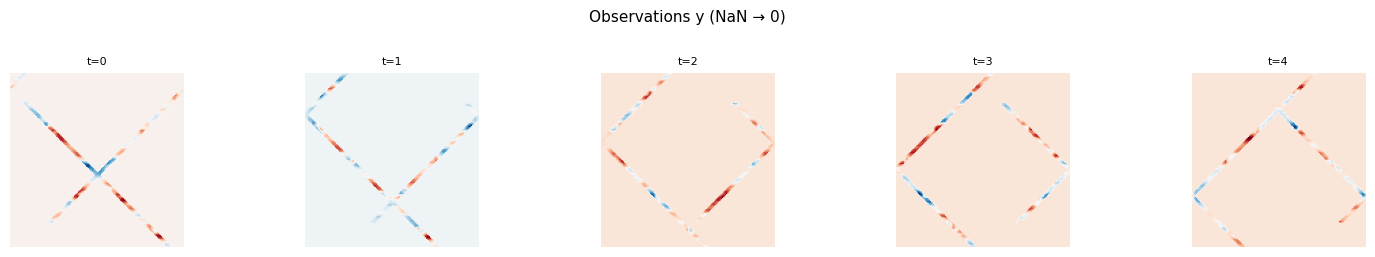

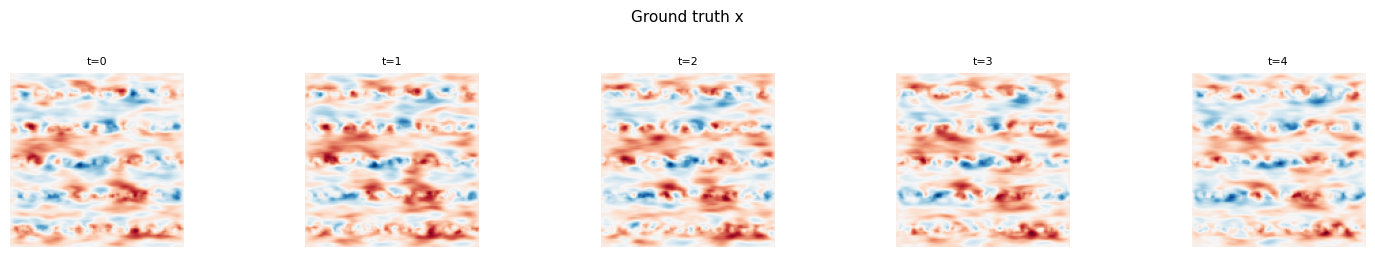

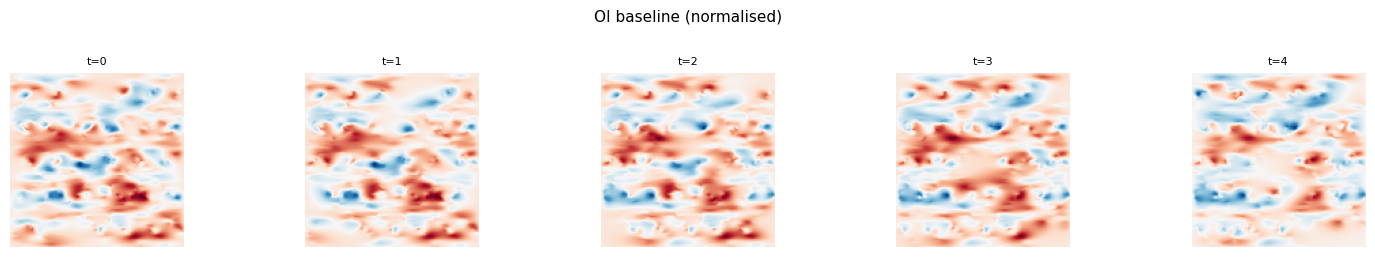

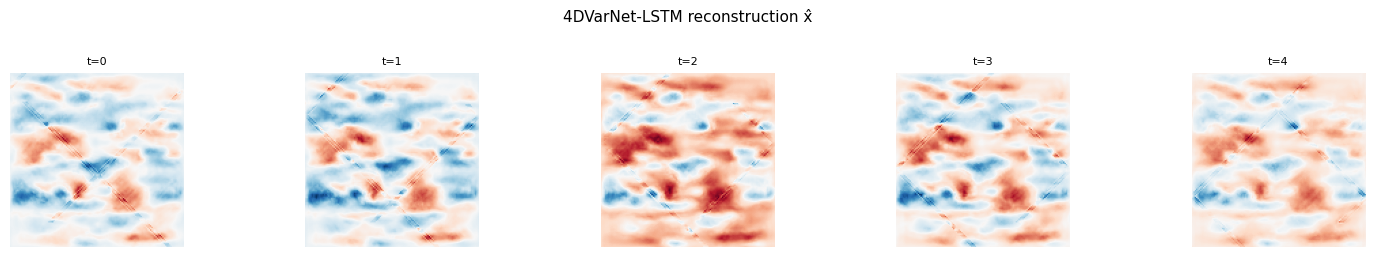

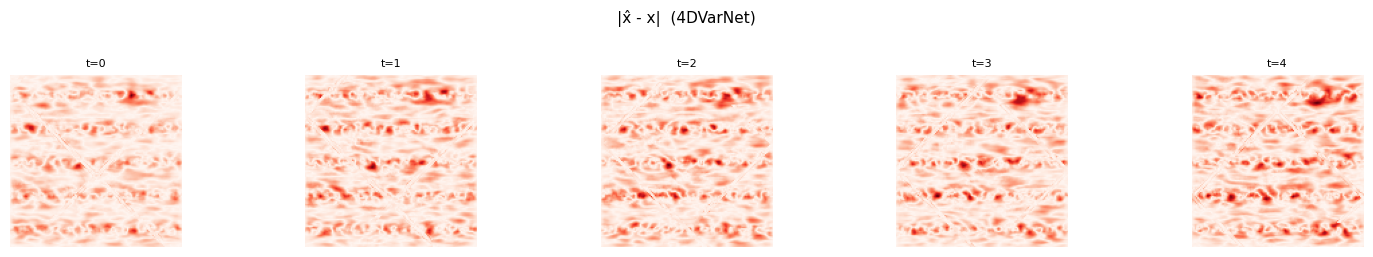

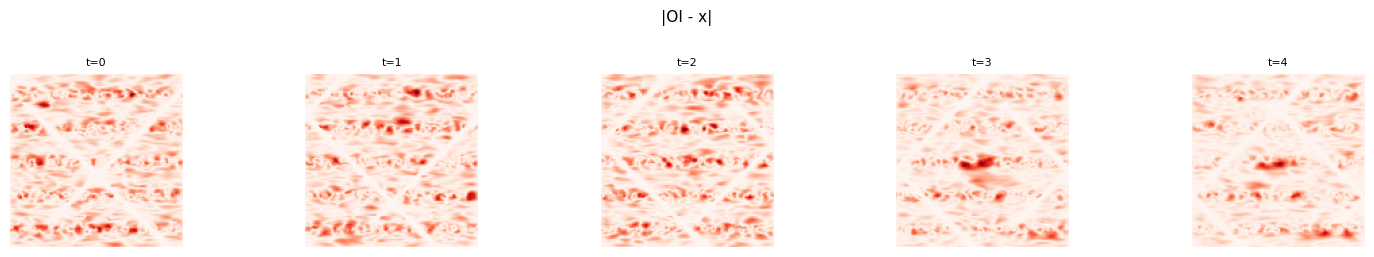

In [42]:
def plot_field(arr: np.ndarray, title: str = "", vmin=None, vmax=None,
               cols: int = 5, cmap: str = "RdBu_r") -> None:
    """Plot a (T, H, W) field as a grid of T maps."""
    T = arr.shape[0]
    rows = math.ceil(T / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.5 * rows))
    axes = np.array(axes).ravel()
    for t in range(T):
        im = axes[t].imshow(arr[t], origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
        axes[t].set_title(f"t={t}", fontsize=8)
        axes[t].axis("off")
    for ax in axes[T:]:
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()


# ---- Test batch ----
seed_everything(42)
batch  = next(iter(datamodule.test_dataloader()))
y      = batch.input.to(device=device, dtype=dtype)
x_true = batch.tgt  .to(device=device, dtype=dtype)

mask     = y.isfinite().to(dtype)
y_filled = y.nan_to_num(0.0)

with torch.no_grad():
    iterates = solver(y_filled, mask, return_all_iterates=True)

b = 0
x_hat = iterates[-1].detach()

# ---- OI baseline (same time window as test sample) ----
m_norm, s_norm = datamodule.norm_stats()
start_t = datamodule.test_ds.indices[0]
ws      = datamodule.window_size
oi_np   = datamodule.oi[start_t : start_t + ws].astype(np.float32)   # physical units
oi_norm = (oi_np - m_norm) / s_norm                                    # normalised

rmse    = (x_hat - x_true).pow(2).mean().sqrt().item()
rmse_oi = np.sqrt(np.nanmean((oi_norm - x_true[b].float().cpu().numpy()) ** 2))
print(f"RMSE 4DVarNet (final iterate vs x_true): {rmse:.4f}")
print(f"RMSE OI       (vs x_true, normalised)  : {rmse_oi:.4f}")

plot_field(y_filled[b].float().cpu().numpy(), title="Observations y (NaN → 0)")
plot_field(x_true  [b].float().cpu().numpy(), title="Ground truth x")
plot_field(oi_norm,                            title="OI baseline (normalised)")
plot_field(x_hat   [b].float().cpu().numpy(), title=f"4DVarNet-{SOLVER_TYPE.upper()} reconstruction x̂")
plot_field(np.abs(x_hat[b].float().cpu().numpy() - x_true[b].float().cpu().numpy()),
           title="|x̂ - x|  (4DVarNet)", vmin=0, cmap="Reds")
plot_field(np.abs(oi_norm - x_true[b].float().cpu().numpy()),
           title="|OI - x|", vmin=0, cmap="Reds")


### Solver convergence — RMSE per iteration

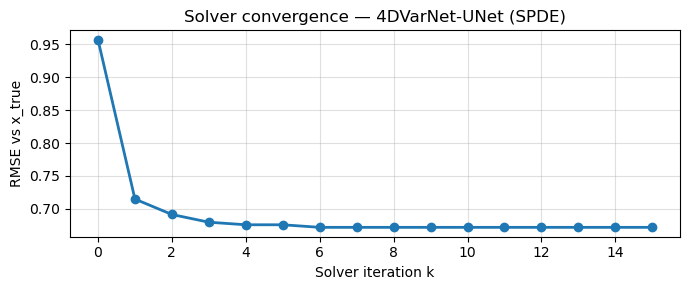

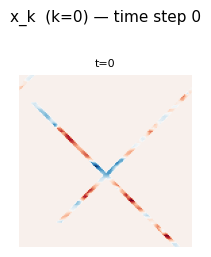

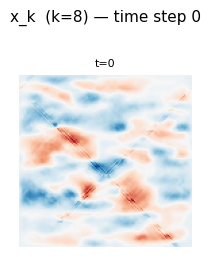

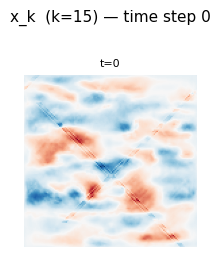

In [43]:
rmse_per_iter = [
    (xk[b:b+1].detach() - x_true[b:b+1]).pow(2).mean().sqrt().item()
    for xk in iterates
]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(len(rmse_per_iter)), rmse_per_iter, marker='o', linewidth=2)
ax.set_xlabel("Solver iteration k")
ax.set_ylabel("RMSE vs x_true")
ax.set_title("Solver convergence — 4DVarNet-UNet (SPDE)")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Show x_0, x_{N/2}, x_N for time step 0
for k_show in [0, len(iterates) // 2, len(iterates) - 1]:
    xk_np = iterates[k_show][b, :1].detach().float().cpu().numpy()
    plot_field(xk_np, title=f"x_k  (k={k_show}) — time step 0", cols=1)


### Spectral Metrics & Benchmarking vs OI

Compare **4DVarNet-UNet** against the **Optimal Interpolation** baseline on:
- μ-score = $1 - \text{RMSE}/\sigma_\text{GT}$
- RMSE
- Minimal resolved wavelength $\lambda_x$ (radial PSD)
- Spectral correlation


## Performance Assessment — 4DVarNet-UNet vs OI (SPDE dataset)

| Method        |   mu_score |   RMSE |   lambda_x_GT |   lambda_x_pred |   spectral_corr |
|:--------------|-----------:|-------:|--------------:|----------------:|----------------:|
| 4DVarNet-UNet |     0.3136 | 0.2497 |           inf |             inf |          0.968  |
| OI baseline   |     0.3982 | 0.2189 |           inf |             inf |          0.9972 |


/tmp/ipykernel_3167097/273822912.py:33: RuntimeWarning: divide by zero encountered in divide
  lambda_x  = (nx * dx) / idx_50[0] if len(idx_50) > 0 else np.nan


,mu_score,RMSE,lambda_x_GT,lambda_x_pred,spectral_corr
Method,,,,,
4DVarNet-UNet,0.3136,0.2497,inf,inf,0.9680
OI baseline,0.3982,0.2189,inf,inf,0.9972


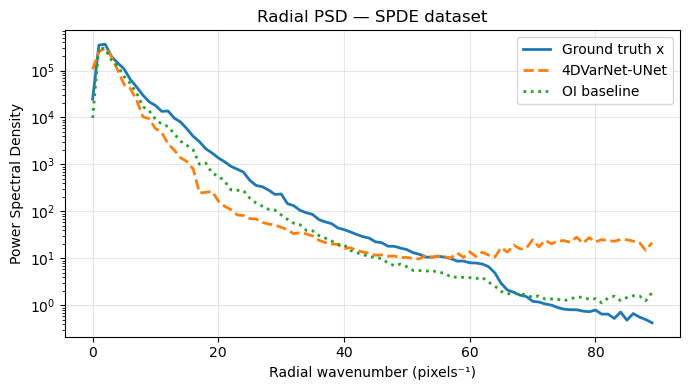

In [44]:
# ---- Retrieve full-domain arrays (denormalized back to physical units) ----
# datamodule.oi / .x / .y are always in original units.
# x_hat and x_true here are normalised; we use the norm_stats to convert back.
m_norm, s_norm = datamodule.norm_stats()

gt_np    = x_true[b].float().cpu().numpy() * s_norm + m_norm   # (T, H, W)
xhat_np  = x_hat [b].float().cpu().numpy() * s_norm + m_norm

# OI: select the same time window as this test sample
# (datamodule.oi is the full (T=15, H, W) array)
start_t  = datamodule.test_ds.indices[0]
ws       = datamodule.window_size
oi_np    = datamodule.oi[start_t : start_t + ws].astype(np.float32)   # (T, H, W)


def compute_psd_and_lambda_x(field: np.ndarray, dx: float = 1.0):
    """Radial PSD and minimal resolved wavelength lambda_x."""
    f = field.copy()
    f[np.isnan(f)] = 0.0
    psd_sum = sum(np.abs(np.fft.fft2(f[t])) ** 2 for t in range(f.shape[0]))
    psd_avg = psd_sum / f.shape[0]
    ny, nx  = psd_avg.shape
    yy, xx  = np.meshgrid(np.arange(ny) - ny // 2, np.arange(nx) - nx // 2, indexing='ij')
    rr      = np.sqrt(xx ** 2 + yy ** 2)
    r_max   = int(np.sqrt((ny // 2) ** 2 + (nx // 2) ** 2))
    radial_psd = np.array([
        np.mean(np.fft.fftshift(psd_avg)[(rr >= r) & (rr < r + 1)])
        if np.any((rr >= r) & (rr < r + 1)) else 0.0
        for r in range(r_max)
    ])
    threshold = 0.5 * np.max(radial_psd[1:])
    idx_50    = np.where(radial_psd < threshold)[0]
    lambda_x  = (nx * dx) / idx_50[0] if len(idx_50) > 0 else np.nan
    return lambda_x, radial_psd


def metrics_vs_gt(pred: np.ndarray, gt: np.ndarray, label: str, dx: float = 1.0):
    gt_std   = np.nanstd(gt)
    rmse_v   = np.sqrt(np.nanmean((pred - gt) ** 2))
    mu       = 1.0 - rmse_v / gt_std
    lx_gt,   psd_gt   = compute_psd_and_lambda_x(gt,   dx=dx)
    lx_pred, psd_pred = compute_psd_and_lambda_x(pred, dx=dx)
    spectral = np.corrcoef(psd_gt[:len(psd_gt)//2], psd_pred[:len(psd_pred)//2])[0, 1]
    return dict(Method=label, mu_score=mu, RMSE=rmse_v,
                lambda_x_GT=lx_gt, lambda_x_pred=lx_pred, spectral_corr=spectral), psd_pred, psd_gt


dx_pixel = 1.0   # pixel spacing (update with physical resolution if known)
row_4dvar, psd_4dvar, psd_gt = metrics_vs_gt(xhat_np, gt_np, "4DVarNet-UNet", dx=dx_pixel)
row_oi,    psd_oi,   _       = metrics_vs_gt(oi_np,   gt_np, "OI baseline",    dx=dx_pixel)

df = pd.DataFrame([row_4dvar, row_oi])
df = df.set_index("Method")
df["mu_score"]      = df["mu_score"].map("{:.4f}".format)
df["RMSE"]          = df["RMSE"].map("{:.4f}".format)
df["lambda_x_GT"]   = df["lambda_x_GT"].map(lambda v: f"{v:.2f}" if not np.isnan(v) else "N/A")
df["lambda_x_pred"] = df["lambda_x_pred"].map(lambda v: f"{v:.2f}" if not np.isnan(v) else "N/A")
df["spectral_corr"] = df["spectral_corr"].map("{:.4f}".format)

print("## Performance Assessment — 4DVarNet-UNet vs OI (SPDE dataset)\n")
print(df.to_markdown())
display(df)

# ---- PSD comparison plot ----
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(psd_gt,    label="Ground truth x",  linewidth=2)
ax.semilogy(psd_4dvar, label="4DVarNet-UNet",    linewidth=2, linestyle="--")
ax.semilogy(psd_oi,    label="OI baseline",      linewidth=2, linestyle=":")
ax.set_xlabel("Radial wavenumber (pixels⁻¹)")
ax.set_ylabel("Power Spectral Density")
ax.set_title("Radial PSD — SPDE dataset")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
